### Notebook Overview: Data Loading and Initial Cleaning

This notebook loads the Telco Customer Churn dataset from Kaggle into a pandas DataFrame. Initial cleaning involves normalizing column names to lowercase and converting the `totalcharges` column to a float by replacing spaces with zeros.

### Notebook Overview
This notebook performs initial data loading, inspection, and cleaning steps for the Telco Customer Churn dataset.

#### 1. Mount Google Drive
This cell mounts your Google Drive to the Colab environment, which can be useful for storing or accessing files from Drive. While not directly used for the Kaggle dataset in this specific case, it's a common setup step.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

#### 2. Download Kaggle Dataset
This block uses the `kagglehub` library to download the `telco-customer-churn` dataset. It then identifies the `.csv` file within the downloaded directory and sets `csv_file_path` to point to it. This ensures that the correct data file is used for subsequent steps.

In [ ]:
import os
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    file_name = csv_files[0]
    print(f"Automatically detected CSV file: {file_name}")
else:
    file_name = 'dataset.csv'
    print(f"No CSV file detected, using default filename: {file_name}")

csv_file_path = os.path.join(path, file_name)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Automatically detected CSV file: WA_Fn-UseC_-Telco-Customer-Churn.csv


#### 3. Load Data and Initial Inspection (Cell `ChVsy42NoQFL`)
Here, essential libraries like `pandas`, `numpy`, `matplotlib`, and `seaborn` are imported. The identified CSV file is read into a pandas DataFrame named `df`, and the first 5 rows (`df.head()`) are displayed to give a quick overview of the data structure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(csv_file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 4. Display DataFrame Information (Cell `44gU1ynio9AH`)
The `df.info()` method provides a concise summary of the DataFrame, including the number of entries, the number of non-null values for each column, and the data types (`Dtype`) of each column. This is crucial for identifying missing values and incorrect data types early on.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### 5. Normalize Column Names
This step converts all column names in the DataFrame to lowercase using `df.columns = df.columns.str.lower()`. This practice helps in maintaining consistency and avoids potential issues with case sensitivity during analysis.

In [ ]:
df.columns = df.columns.str.lower()
df.info()

#### 6. Clean `totalcharges` Column
The `totalcharges` column was initially of `object` (string) type, and `df.info()` revealed that it might contain non-numeric values (specifically, spaces). This cell performs two critical cleaning steps:
1.  **Replace spaces with 0**: `df['totalcharges'].replace(' ',0)` converts any spaces in the column to `0`. This is a common approach when such values might represent new customers with no charges yet.
2.  **Convert to float**: `df['totalcharges'].astype('float')` casts the cleaned column to a numeric (float) data type, enabling numerical operations. The `df.info()` is called again to confirm the data type change.

In [ ]:
df['totalcharges'] = df['totalcharges'].replace(' ',0)
df['totalcharges'] = df['totalcharges'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [ ]:
df.isnull().sum()
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.duplicated().sum()
df['customerid'].duplicated().sum()

np.int64(0)

 Coverted 0 and 1 value of `seniorcitizen` to Yes/No to make it easier to understand

In [ ]:
# def conv(value):
#   if value==1: return 'Yes'
#   else: return 'No'
# df['seniorcitizen'] = df['seniorcitizen'].apply(conv)

df['seniorcitizen'] = df['seniorcitizen'].apply(lambda x: 'Yes' if x==1 else 'No')

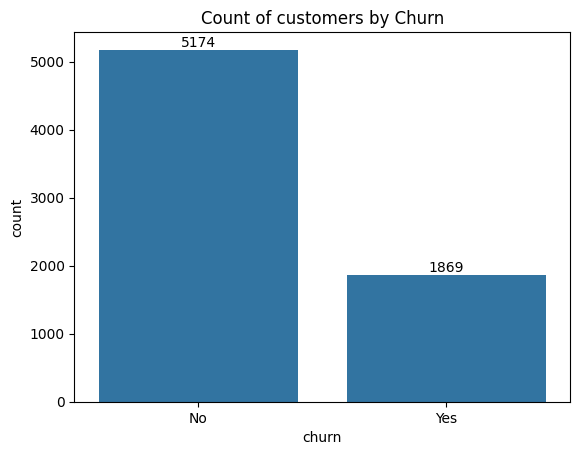

In [ ]:
ax = sns.countplot(data=df, x=df['churn'])
ax.bar_label(ax.containers[0])
plt.title('Count of customers by Churn')
plt.show()

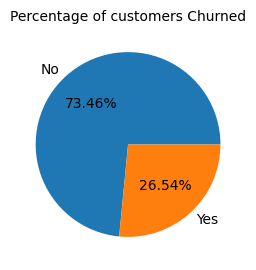

In [ ]:
#gb = df.groupby('churn').agg({'churn':'count'})
# plt.pie(gb['churn'])

gb = df['churn'].value_counts(normalize = True)
plt.figure(figsize=(3,3))
plt.pie(gb, labels=gb.index, autopct = '%1.2f%%')
plt.title('Percentage of customers Churned', fontsize=10)
plt.show()

From the given pie chart we can conclude that 26.54% of our customers have churned out

Now let's explore the reason behind it

### Churn by Gender

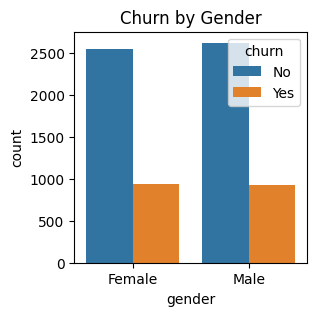

In [ ]:
plt.figure(figsize=(3,3))
plt.title('Churn by Gender')
sns.countplot(x='gender',data=df, hue = 'churn')
plt.show()

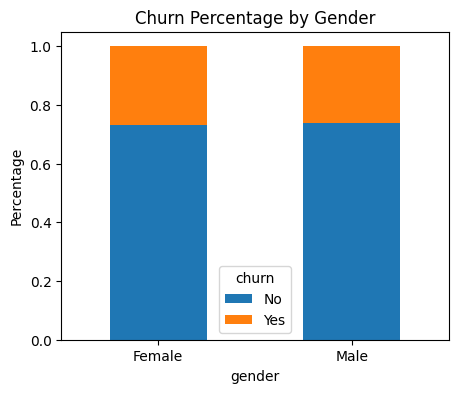

In [ ]:
churn_by_gender = df.groupby('gender')['churn'].value_counts(normalize=True).unstack()
churn_by_gender.plot(kind='bar', stacked=True, figsize=(5,4))
plt.title('Churn Percentage by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

### Churn by Senior Citizen Status

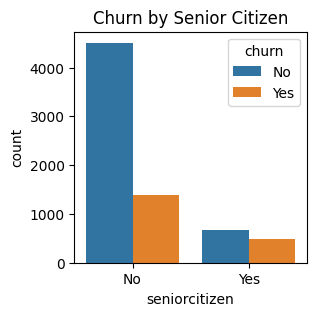

In [ ]:
plt.figure(figsize=(3,3))
plt.title('Churn by Senior Citizen')
sns.countplot(x='seniorcitizen',data=df, hue='churn')
plt.show()

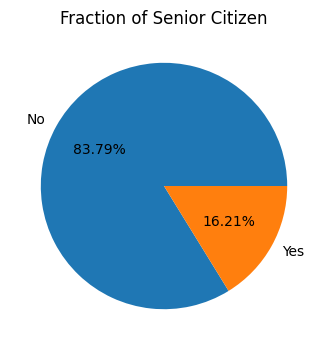

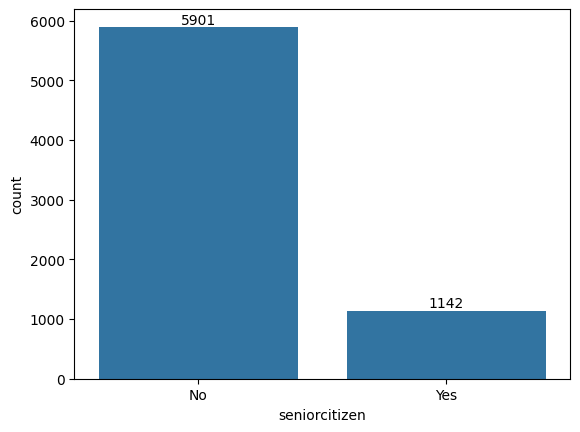

In [ ]:
plt.figure(figsize=(4,4))
plt.title('Fraction of Senior Citizen')

gb = df['seniorcitizen'].value_counts()
plt.pie(gb, labels = gb.index, autopct = '%1.2f%%')
plt.show()

ax = sns.countplot(x='seniorcitizen',data=df)
ax.bar_label(ax.containers[0])
plt.show()

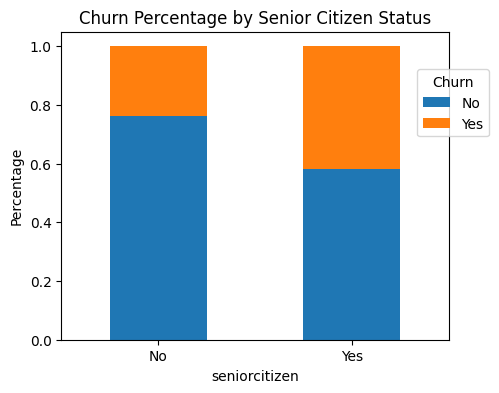

In [ ]:
gb = df.groupby('seniorcitizen')['churn'].value_counts(normalize=True).unstack()
gb.plot(kind='bar', stacked=True, figsize=(5,4))
plt.title('Churn Percentage by Senior Citizen Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn',bbox_to_anchor=(0.9,0.9))
plt.show()

# comparatively a greater pecentage of people in senior citizen category have churned

<Axes: xlabel='tenure', ylabel='Count'>

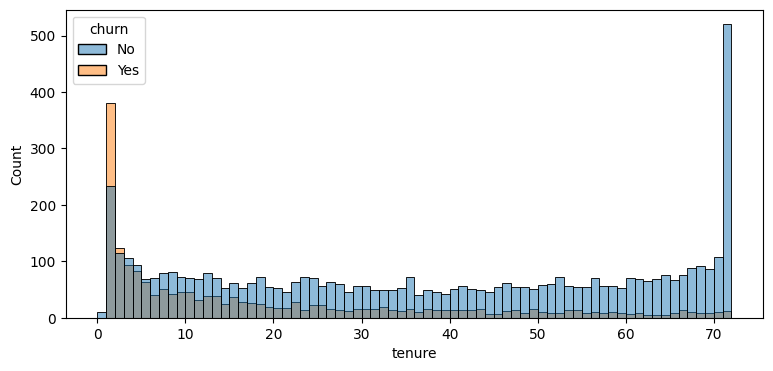

In [ ]:
plt.figure(figsize=(9,4))
sns.histplot(data=df,x='tenure', bins=72, hue='churn')

people who have used our services for more than 2 months have stayed and people who have used for 1 or 2 months have churned

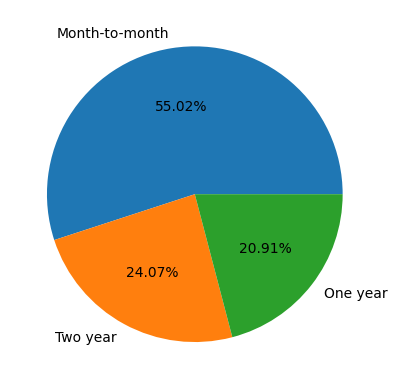

In [ ]:
gb = df['contract'].value_counts()
plt.pie(gb, labels = gb.index, autopct = '%1.2f%%')
plt.show()

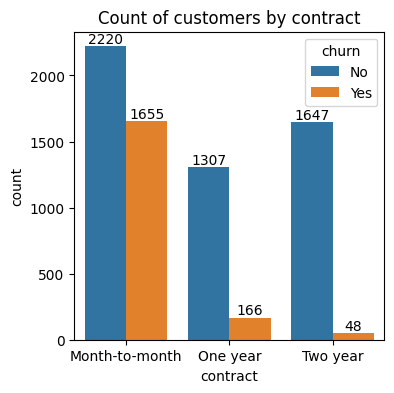

In [ ]:
plt.figure(figsize=(4,4))
plt.title('Count of customers by contract')
ax = sns.countplot(data=df, x='contract', hue='churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

people who have month-to-month contract are likely to churn from those who have 1 or 2 years of contract

In [ ]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

### Churn Analysis by Service Features

These plots visualize the distribution of customer churn across various service-related features like phone service, multiple lines, internet service, online security, and more. Each subplot is a countplot, showing the number of customers in each category, broken down by whether they churned or not.

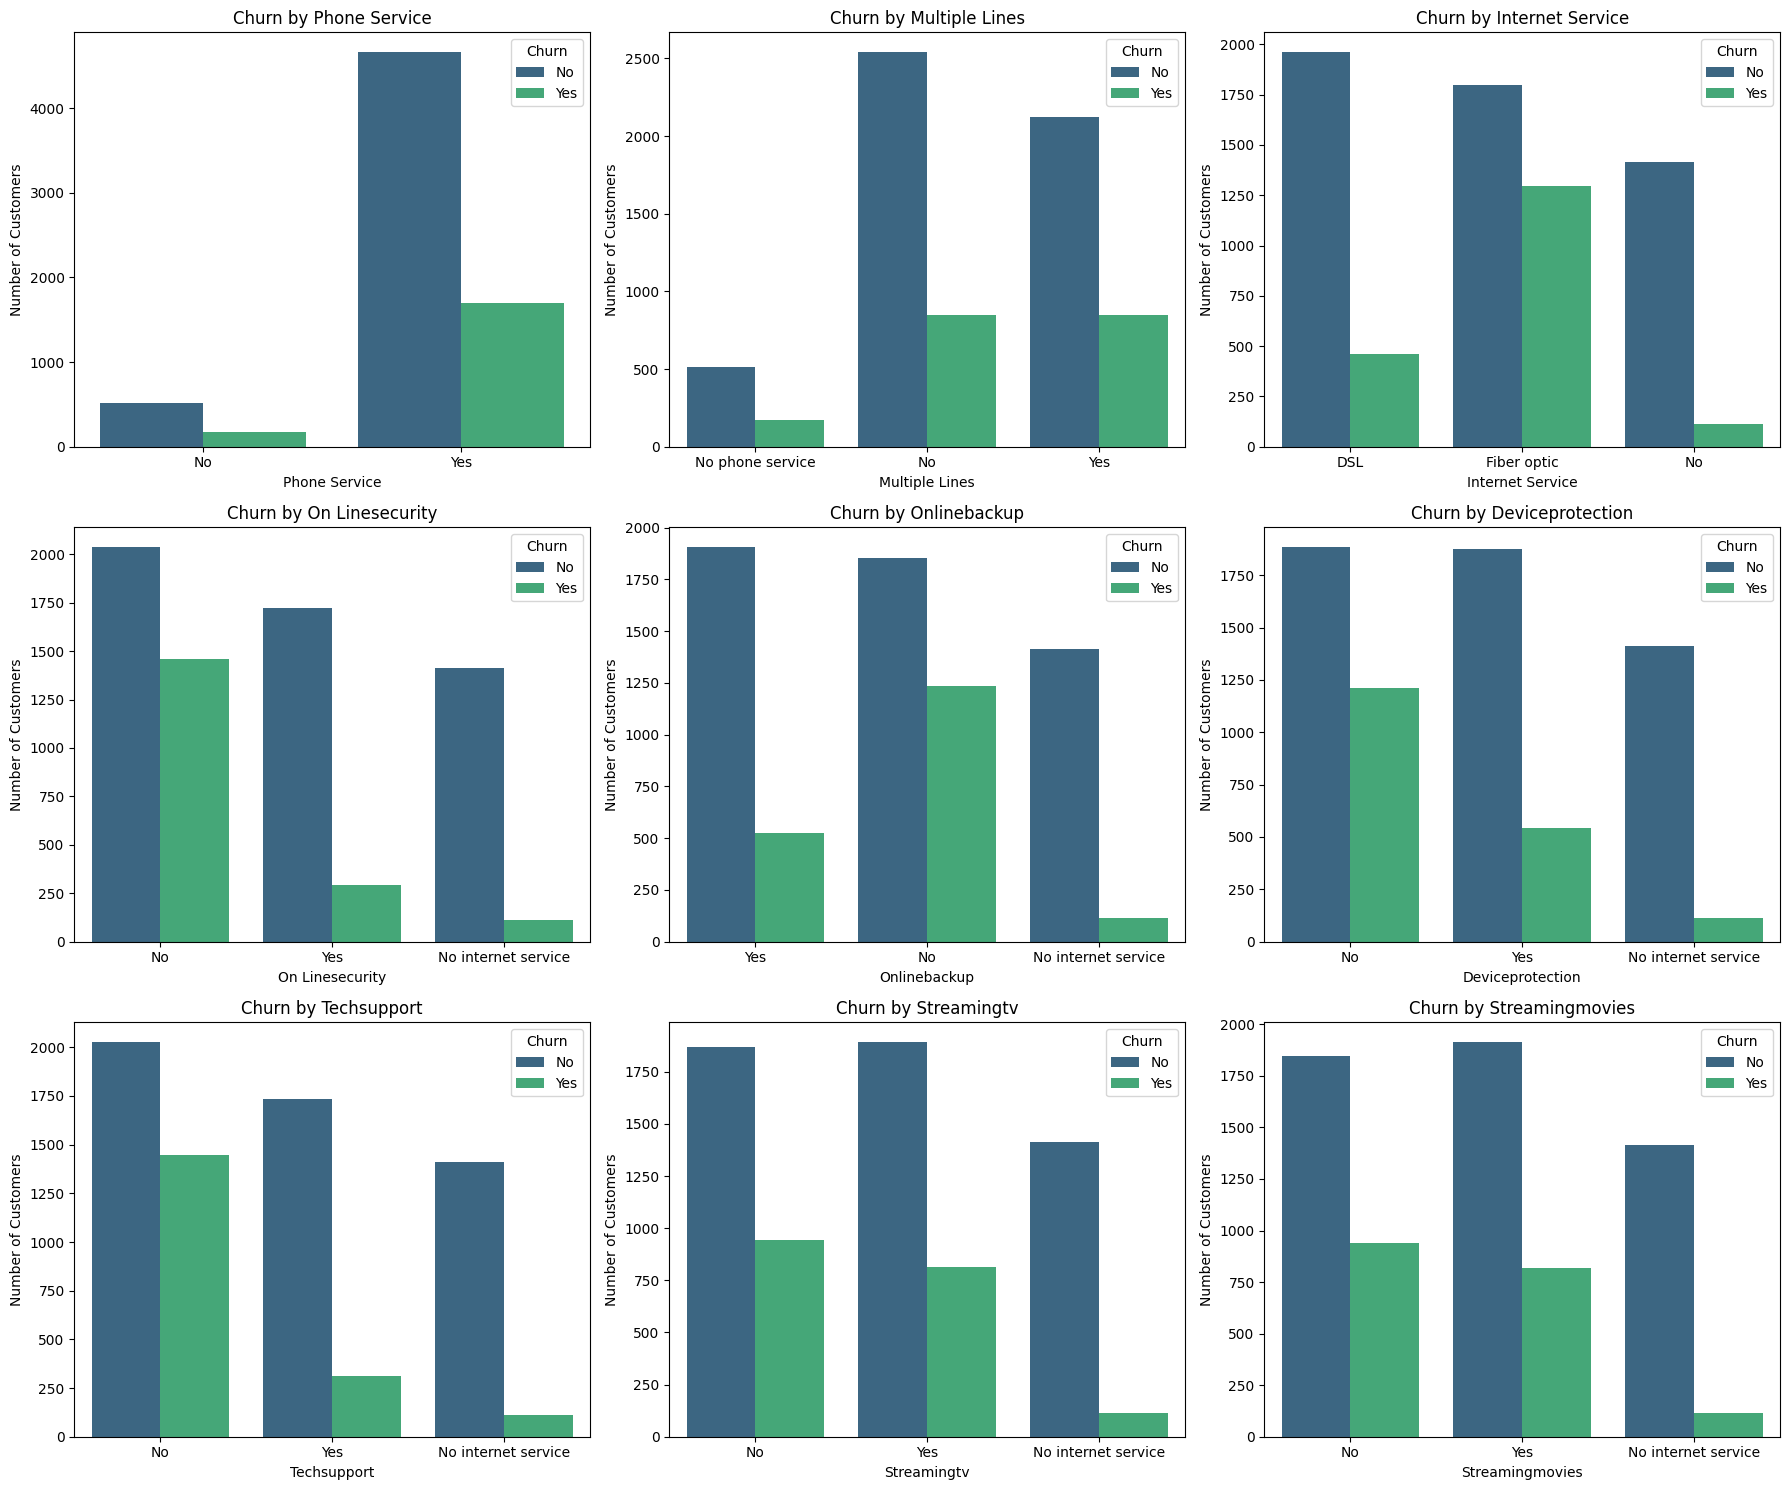

In [ ]:
# Gemini Prompt - 'phoneservice', 'multiplelines'..... in columns se mujhe subplots
# banana hai jisme har ek plot count plot hoga

features = [
    'phoneservice', 'multiplelines', 'internetservice',
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feature in enumerate(features):
    sns.countplot(data=df, x=feature, hue='churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn by {feature.replace("service", " Service").replace("lines", " Lines").title()}')
    axes[i].set_xlabel(feature.replace("service", " Service").replace("lines", " Lines").title())
    axes[i].set_ylabel('Number of Customers')
    axes[i].legend(title='Churn')

plt.tight_layout()
plt.show()

### Kam Churn Wale Customers:

Jinke paas phone service nahi hai ('No phone service').

Jinke paas internet service nahi hai ('No internet service').

### Zyada Churn Wale Customers:

Jo 'Fiber optic' internet service use karte hain.

Jinke paas 'Online Security' nahi hai ('No OnlineSecurity').

Jinke paas 'Online Backup' nahi hai ('No OnlineBackup').

Jinke paas 'Device Protection' nahi hai ('No DeviceProtection').

Jinke paas 'Tech Support' nahi hai ('No TechSupport').

Jo 'Streaming TV' ya 'Streaming Movies' service lete hain (haan, inmein bhi churn zyada dikh raha hai)

### Solutions to Reduce Churn

Ab jab humein pata chal gaya hai ki kaun se customers zyada churn kar rahe hain, toh yeh rahe kuch solutions aur recommendations jinse hum churn kam kar sakte hain:

**1. Security aur Support Services ko Badhawa do (Promote Security and Support Services):**
*   Jin customers ke paas 'Online Security', 'Online Backup', 'Device Protection', ya 'Tech Support' jaisi services nahi hain, unhe inki importance batao. Offer do, jaise pehle kuch mahine free, ya kisi plan ke saath bundle kar do.
*   Samjhao ki yeh services unke data aur devices ko secure rakhti hain, aur problems aane par help karti hain. Isse unka trust badhega.

**2. Fiber Optic Users Par Khaas Dhyaan Do (Focus on Fiber Optic Users):**
*   'Fiber optic' internet users mein churn zyada hai, toh yeh samajhna zaroori hai ki unhe kya dikkat aa rahi hai. Kya speed mein problem hai, ya customer service theek nahi hai, ya price zyada lag raha hai?
*   Unke liye special offers ya loyalty programs shuru karo, ya unke feedback par tezi se kaam karo.

**3. Streaming Services Ki Quality aur Content Check Karo (Check Quality and Content for Streaming Services):**
*   Jo customers 'Streaming TV' ya 'Streaming Movies' use kar rahe hain, woh bhi churn kar rahe hain. Shayad content pasand nahi aa raha, buffering ki problem hai, ya dusri services better options de rahi hain.
*   Regularly naye content add karo, streaming quality theek rakho, aur user experience ko behtar banane par kaam karo.

**4. Month-to-Month Contract Walon ko Samjhao (Educate Month-to-Month Contract Holders):**
*   Jaisa ki pehle analysis mein dekha, 'Month-to-month' contract wale zyada churn karte hain. Unhe lambe contracts ke fayde batao, jaise kam bill ya additional benefits.
*   Unhe 'One year' ya 'Two year' contracts mein shift karne ke liye incentives do.

**5. Naye Customers Par Focus (Focus on New Customers):**
*   Jo customers shuru ke kuch mahino mein hi churn kar rahe hain ('tenure' analysis se pata chala), unke liye onboarding process ko better banao.
*   Shuruati mahino mein unse regular feedback lo aur unki problems ko jaldi solve karo takay woh comfortable feel karein.

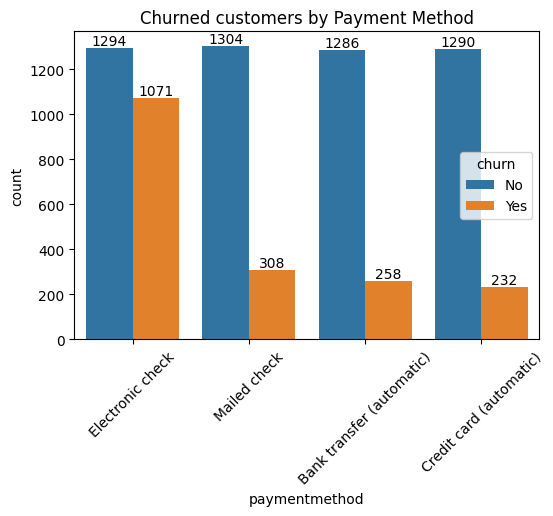

In [ ]:
plt.figure(figsize=(6,4))
plt.title('Churned customers by Payment Method')
ax = sns.countplot(data=df, x='paymentmethod', hue='churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation=45 )
plt.show()

### customer is likely to churn when he is using electronic check as a payment method
If a customer has to actively remember to pay each month, they might be more likely to miss a payment, leading to service issues, or simply find it a hassle and look for alternatives.

Promoting Autopayment (e.g., direct debit, credit card autopay) as the primary payment method can help reduce this churn by:

* Reducing Payment Friction: Payments are automatic, so customers don't have to remember to pay, reducing the chances of missed payments and service interruptions.
* Improving Convenience: It's more convenient for the customer, leading to higher satisfaction.
* Increasing Retention: Customers on autopay are generally 'stickier' because the payment process is seamless and they are less likely to actively think about canceling their service due to payment-related frustrations.
So, the solution suggests actively encouraging or even incentivizing customers (especially those currently using electronic checks) to switch to an autopayment method to improve their payment experience and reduce their likelihood of churning.